# PGD Adversarial Attacks

## Projected Gradient Descent - Implementazione e Valutazione

Questo notebook implementa attacchi PGD da zero e valuta l'accuratezza del modello ResNet18 addestrato

## 1. Setup e Import

In [1]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROOT = Path('..')
BATCH_SIZE = 32
IMG_SIZE = 224
N_CLASSES = 5


model = models.resnet18(pretrained=True)
model.fc = nn.Linear(in_features=512, out_features=N_CLASSES)
model = model.to(device)

model_path = ROOT / "models" / "best_resnet18.pt"
model.load_state_dict(torch.load(model_path))
model.eval()


NORMALIZE = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

TRANSFORMS = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

dataset_path = ROOT / "data" / "fruits-classification-stratified"

train_dataset = ImageFolder(root=dataset_path / 'train', transform=TRANSFORMS)
val_dataset = ImageFolder(root=dataset_path / 'valid', transform=TRANSFORMS)
test_dataset = ImageFolder(root=dataset_path / 'test', transform=TRANSFORMS)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

class_names = test_dataset.classes

results_path = ROOT / "results"
results_path.mkdir(exist_ok=True)

print(f"\nSetup e import completati")


Setup e import completati


/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## 2. Implementazione PGD (da zero)

PGD (Projected Gradient Descent) è una versione iterativa di FGSM:

1. Parte da un intorno di epsilon 
2. Ad ogni iterazione applica FGSM con step size alpha
3. Si assicura che la perturbazione totale sia all'interno del range
4. Ripete le operazioni per n iterazioni

In [2]:
def pgd_attack(model, images, labels, epsilon, alpha, num_steps, loss_fn):
    """
    Esegue un attacco PGD su un batch di immagini

    Args:
        model: il modello target da ingannare
        images: batch di immagini
        labels: label vere per il batch
        epsilon: raggio massimo della perturbazione (norma inf)
        alpha: step size per ogni iterazione
        num_steps: numero di iterazioni dell'attacco
        loss_fn: funzione di loss (CrossEntropyLoss)

    Returns:
        adv_images: immagini perturbate
        perturbation: il rumore aggiunto
    """

    adv_images = images.clone().detach()

    # partenza casuale
    adv_images = adv_images + torch.empty_like(adv_images).uniform_(-epsilon, epsilon)
    adv_images = torch.clamp(adv_images, 0, 1).detach()

    for _ in range(num_steps):

        adv_images.requires_grad = True

        outputs = model(NORMALIZE(adv_images))
        loss = loss_fn(outputs, labels)

        # pulisce i gradienti precedenti
        model.zero_grad()

        loss.backward()

        # estrae il segno dei gradienti (solo direzione, non ampiezza)
        gradient_sign = adv_images.grad.sign()

        # singola perturbazione (FGSM)
        adv_images = adv_images.detach() + alpha * gradient_sign

        # deve stare all'interno di epsilon
        perturbation = torch.clamp(adv_images - images, -epsilon, epsilon)

        adv_images = torch.clamp(images + perturbation, 0, 1).detach()

    perturbation = adv_images - images

    return adv_images, perturbation.detach()


print("Funzione PGD implementata")

Funzione PGD implementata


## 3. Test PGD con Epsilon diversi

Testare l'attacco PGD su diversi valori di epsilon per capire quando il modello inizia a sbagliare.

Metriche:
- **Accuracy**: % di immagini classificate correttamente dal modello (senza attacco)
- **Attack Success Rate (ASR)**: % di immagini dove l'attacco ha ingannato il modello
- **Time**: tempo totale per applicare l'attacco al test set

Problema: usare gli stessi epsilon di FGSM

In [3]:
epsilon_values = [0.0005, 0.001, 0.003, 0.005, 0.01]
epsilon_to_visualize = [0.0005, 0.003, 0.01]

num_steps = 10 

loss_fn = nn.CrossEntropyLoss()
pgd_results = {}

examples_store = {eps: {'success': [], 'failure': []} for eps in epsilon_to_visualize}

for epsilon in epsilon_values:
    alpha = epsilon / 4  # step size standard 
    print(f"\nTest epsilon = {epsilon}, alpha = {alpha:.4f}, num_steps = {num_steps}")

    correct_original = 0
    correct_adv = 0
    attack_success_count = 0
    total_samples = 0

    start_time = time.time()

    model.eval()

    for images, labels in tqdm(test_loader, desc=f"epsilon={epsilon}"):
        images = images.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            outputs_original = model(NORMALIZE(images))
            preds_original = torch.argmax(outputs_original, dim=1)
            correct_original += (preds_original == labels).sum().item()

        # ATTACCO PGD
        adv_images, perturbation = pgd_attack(
            model,
            images.clone().detach(),
            labels,
            epsilon,
            alpha,
            num_steps,
            loss_fn,
        )

        with torch.no_grad():
            outputs_adv = model(NORMALIZE(adv_images))
            preds_adv = torch.argmax(outputs_adv, dim=1)
            correct_adv += (preds_adv == labels).sum().item()

        success = (preds_original == labels) & (preds_adv != labels)
        attack_success_count += success.sum().item()

        total_samples += labels.size(0)

        if epsilon in epsilon_to_visualize:
           for i in range(images.size(0)):
            pred_orig = preds_original[i].item()
            pred_adv = preds_adv[i].item()
            true_label = labels[i].item()

            attack_success = pred_orig == true_label and pred_adv != true_label
            attack_failure = pred_orig == true_label and pred_adv == true_label

            example = {
                'image': images[i:i+1].detach().cpu().clone(),
                'adv_image': adv_images[i:i+1].detach().cpu().clone(),
                'perturbation': perturbation[i:i+1].detach().cpu().clone(),
                'pred_original': pred_orig,
                'pred_adv': pred_adv,
                'true_label': true_label,
            }

            if attack_success: examples_store[epsilon]['success'].append(example)

            elif attack_failure: examples_store[epsilon]['failure'].append(example)

    # metriche
    accuracy = correct_original / total_samples
    accuracy_adv = correct_adv / total_samples
    accuracy_drop = accuracy - accuracy_adv
    asr = attack_success_count / correct_original
    elapsed_time = time.time() - start_time

    pgd_results[epsilon] = {
        'accuracy': accuracy,
        'accuracy_adv': accuracy_adv,
        'accuracy_drop': accuracy_drop,
        'asr': asr,
        'time': elapsed_time,
    }

    print(f"  Accuracy (clean): {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Accuracy (adversarial): {accuracy_adv:.4f} ({accuracy_adv*100:.2f}%)")
    print(f"  Accuracy Drop: {accuracy_drop:.4f} ({accuracy_drop*100:.2f}%)")
    print(f"  Attack Success Rate: {asr:.4f} ({asr*100:.2f}%)")
    print(f"  Tempo: {elapsed_time:.2f}s")

print("\nTest completato per tutti gli epsilon")


Test epsilon = 0.0005, alpha = 0.0001, num_steps = 10


epsilon=0.0005: 100%|██████████| 32/32 [00:04<00:00,  6.98it/s]


  Accuracy (clean): 0.9118 (91.18%)
  Accuracy (adversarial): 0.7866 (78.66%)
  Accuracy Drop: 0.1253 (12.53%)
  Attack Success Rate: 0.1374 (13.74%)
  Tempo: 4.59s

Test epsilon = 0.001, alpha = 0.0003, num_steps = 10


epsilon=0.001: 100%|██████████| 32/32 [00:03<00:00,  9.44it/s]


  Accuracy (clean): 0.9118 (91.18%)
  Accuracy (adversarial): 0.6022 (60.22%)
  Accuracy Drop: 0.3096 (30.96%)
  Attack Success Rate: 0.3396 (33.96%)
  Tempo: 3.39s

Test epsilon = 0.003, alpha = 0.0008, num_steps = 10


...

  Accuracy (clean): 0.9118 (91.18%)
  Accuracy (adversarial): 0.0962 (9.62%)
  Accuracy Drop: 0.8156 (81.56%)
  Attack Success Rate: 0.8945 (89.45%)
  Tempo: 3.77s

Test epsilon = 0.005, alpha = 0.0013, num_steps = 10


epsilon=0.005: 100%|██████████| 32/32 [00:03<00:00,  9.29it/s]


  Accuracy (clean): 0.9118 (91.18%)
  Accuracy (adversarial): 0.0120 (1.20%)
  Accuracy Drop: 0.8998 (89.98%)
  Attack Success Rate: 0.9868 (98.68%)
  Tempo: 3.45s

Test epsilon = 0.01, alpha = 0.0025, num_steps = 10


epsilon=0.01: 100%|██████████| 32/32 [00:03<00:00,  8.24it/s]

  Accuracy (clean): 0.9118 (91.18%)
  Accuracy (adversarial): 0.0000 (0.00%)
  Accuracy Drop: 0.9118 (91.18%)
  Attack Success Rate: 1.0000 (100.00%)
  Tempo: 3.88s

Test completato per tutti gli epsilon


## 4. Plot delle immagini perturbate

Per ogni epsilon verranno mostrate:
- immagini originali
- perturbazioni (rumore aggiunto)
- immagini perturbate (originale + rumore)

Questo aiuta a capire quanto l'attacco sia "visibile" all'occhio umano e come confonde il modello.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.00050002337..0.00050002337].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.00050002337..0.00050002337].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.00050002337..0.00050002337].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.00050002337..0.00050002337].



Epsilon = 0.0005


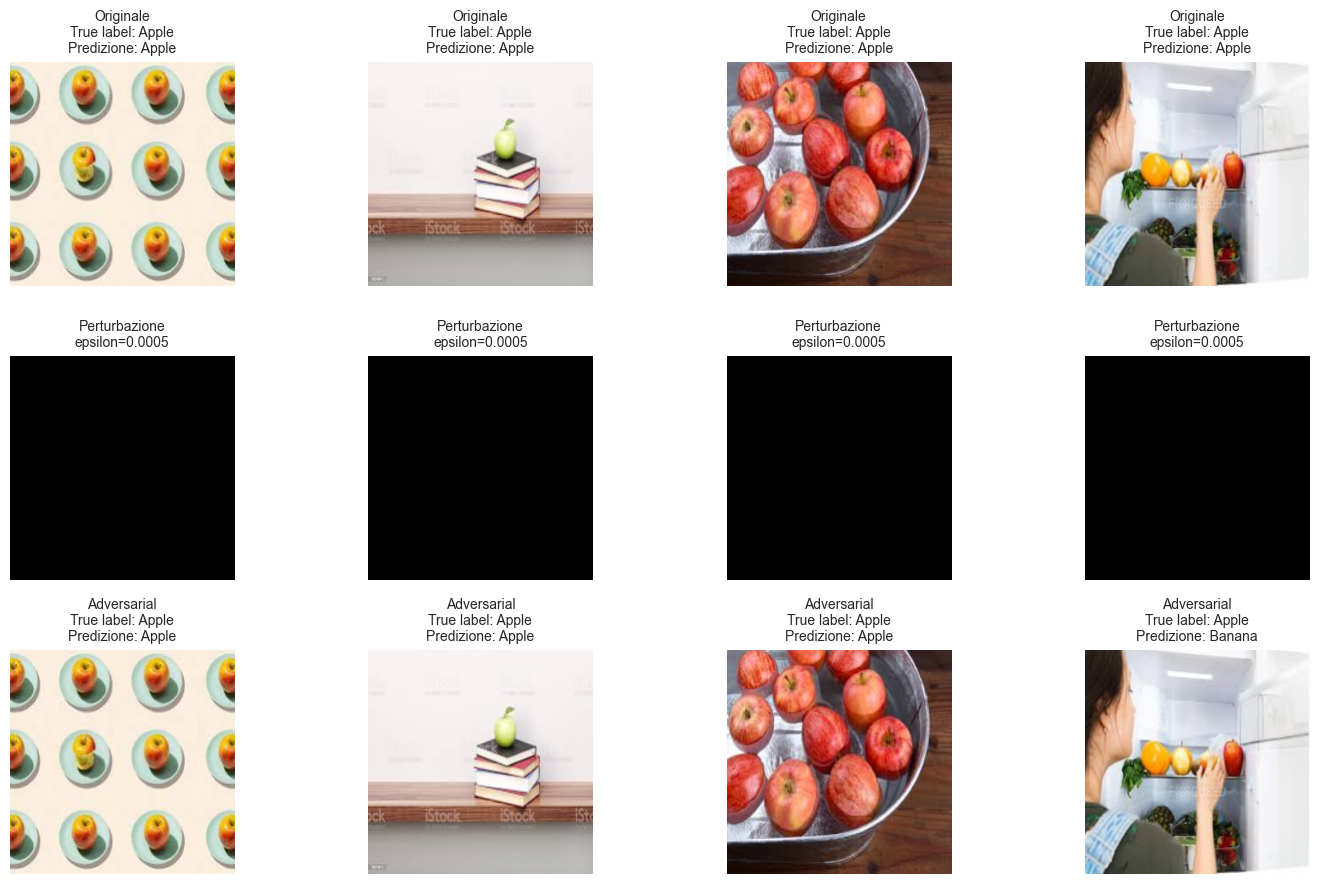

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.003000021..0.003000021].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.003000021..0.003000021].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.003000021..0.003000021].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.003000021..0.003000021].



Epsilon = 0.003


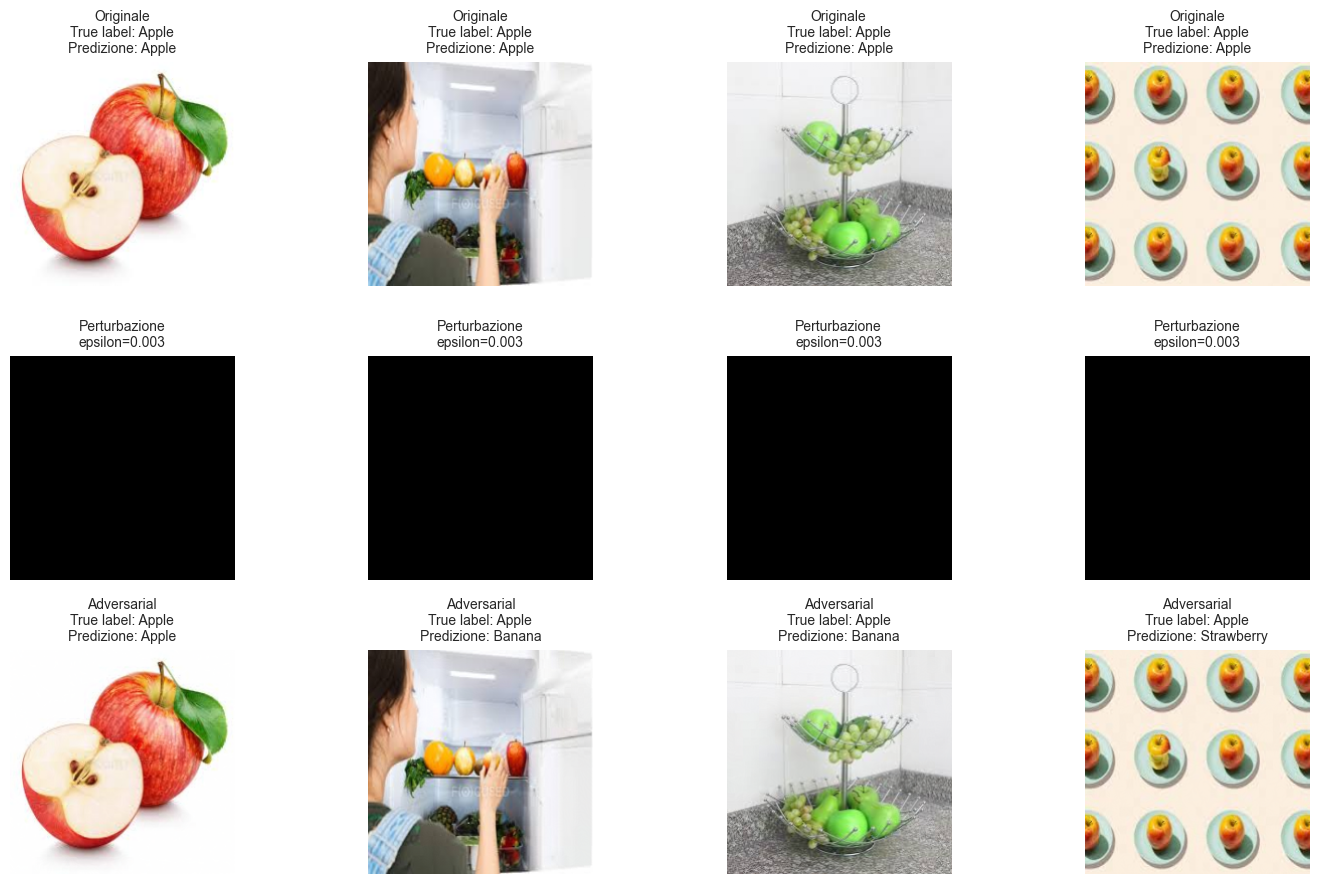

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.010000005..0.01000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.010000005..0.01000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.010000005..0.01000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.010000005..0.01000002].



Epsilon = 0.01


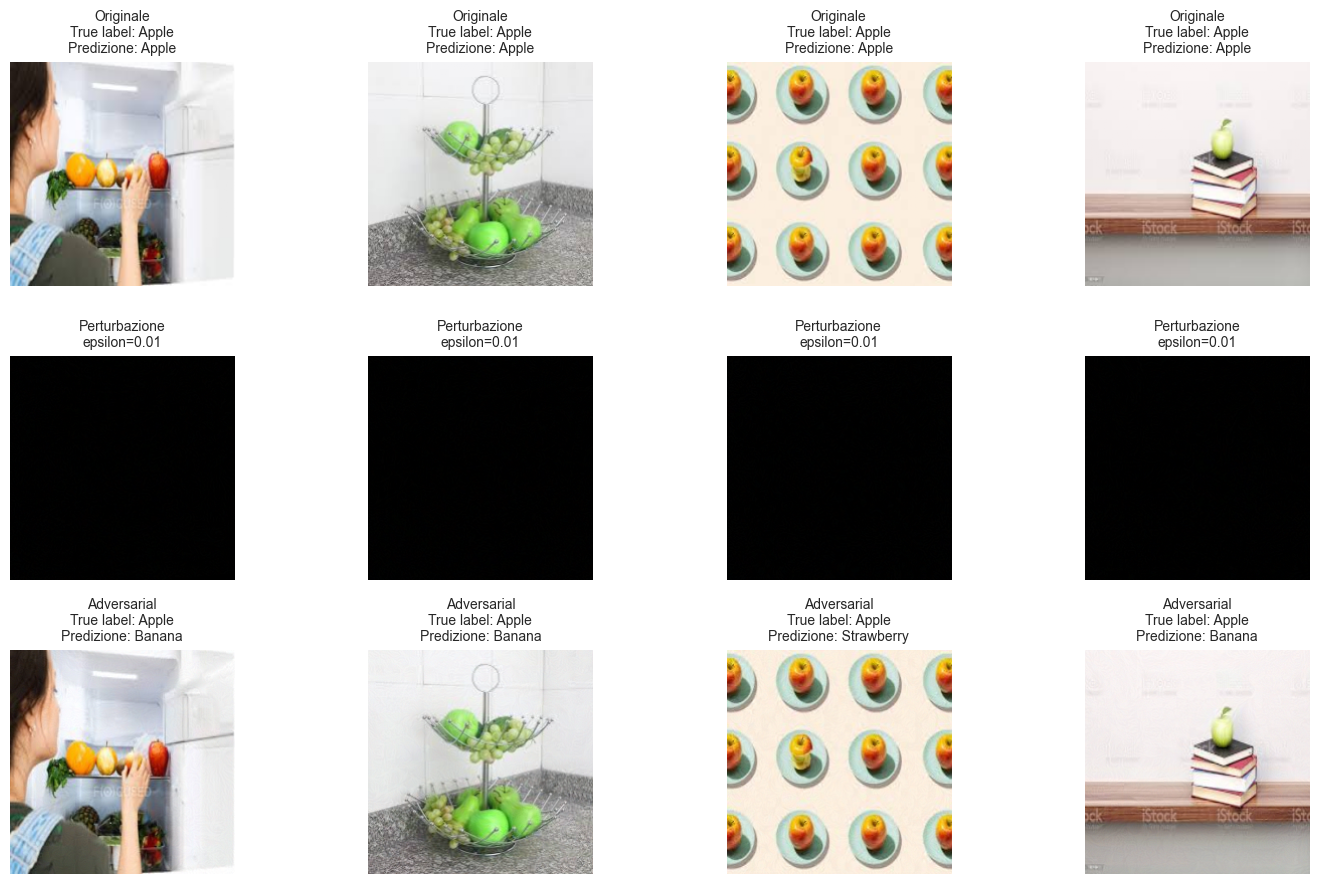

In [8]:
# eps=0.0005: 3 classificate bene + 1 classificata male
# eps=0.003: 1 classificate bene + 3 classificate male
# eps=0.01: 0 classificata bene + 4 classificate male
# scelti arbitrariamente

plot_config = {
    0.0005: {'correct': 3, 'wrong': 1},
    0.003: {'correct': 1, 'wrong': 3},
    0.01: {'correct': 0, 'wrong': 4}, # perche non ce ne sono
}

for epsilon in epsilon_to_visualize:
    selected_examples = (
        examples_store[epsilon]['failure'][:plot_config[epsilon]['correct']] +
        examples_store[epsilon]['success'][:plot_config[epsilon]['wrong']]
    )

    fig, axes = plt.subplots(3, 4, figsize=(15, 9))

    for img_idx in range(4):
        example = selected_examples[img_idx]

        img_original = example['image'][0].numpy()
        img_original = np.transpose(img_original, (1, 2, 0))
        img_original = np.clip(img_original, 0, 1)

        perturbation = example['perturbation'][0].numpy()
        perturbation = np.transpose(perturbation, (1, 2, 0))

        img_adv = example['adv_image'][0].numpy()
        img_adv = np.transpose(img_adv, (1, 2, 0))
        img_adv = np.clip(img_adv, 0, 1)

        true_label = example['true_label']
        pred_original = example['pred_original']
        pred_adv = example['pred_adv']

        # immagini originali
        ax = axes[0, img_idx]
        ax.imshow(img_original)
        ax.set_title(f"Originale\nTrue label: {class_names[true_label]}\nPredizione: {class_names[pred_original]}", fontsize=10)
        ax.axis('off')

        # perturbazioni
        ax = axes[1, img_idx]
        ax.imshow(perturbation)
        ax.set_title(f"Perturbazione\nepsilon={epsilon}", fontsize=10)
        ax.axis('off')

        # immagini adversarial
        ax = axes[2, img_idx]
        ax.imshow(img_adv)
        ax.set_title(f"Adversarial\nTrue label: {class_names[true_label]}\nPredizione: {class_names[pred_adv]}", fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(results_path / f"pgd_attack_{epsilon}.png", dpi=120, bbox_inches='tight')
    print(f"\nEpsilon = {epsilon}")
    plt.show()

## 5. Plot delle Metriche

Generazione di grafici riguardanti le metriche:
- Accuracy su immagini originali vs immagini perturbate
- Calo di accuracy (accuracy drop)
- Attack Success Rate (ASR)
- Tempo per applicare l'attacco al test set

/tmp/ipykernel_2442117/2095513670.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=eps_labels, y=acc_drop, palette='Reds', ax=ax)
/tmp/ipykernel_2442117/2095513670.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=eps_labels, y=asr, palette='Blues', ax=ax)
/tmp/ipykernel_2442117/2095513670.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=eps_labels, y=times, palette='Greens', ax=ax)


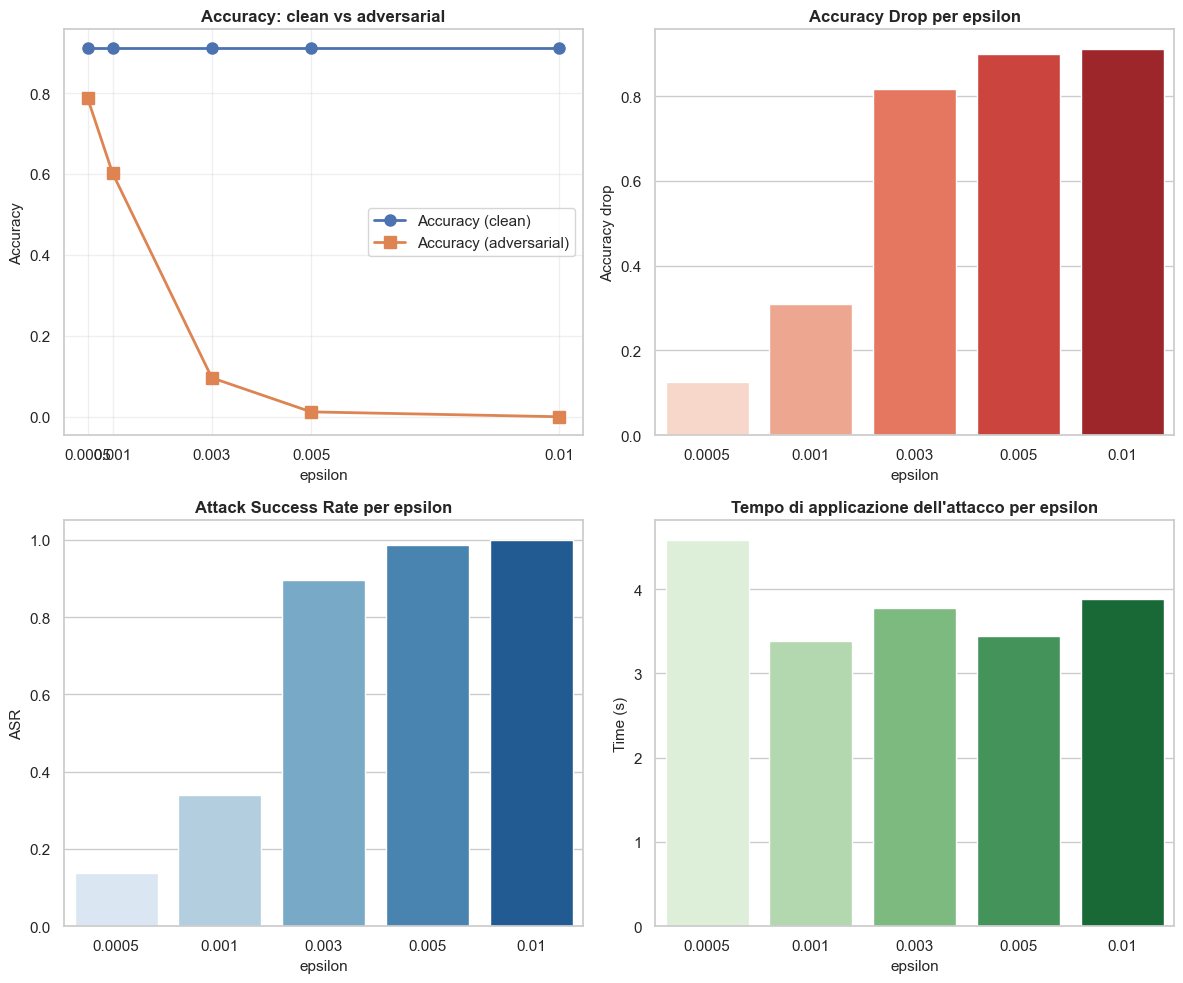

In [5]:
eps = epsilon_values
acc = [pgd_results[e]['accuracy'] for e in eps]
acc_adv = [pgd_results[e]['accuracy_adv'] for e in eps]
acc_drop = [pgd_results[e]['accuracy_drop'] for e in eps]
asr = [pgd_results[e]['asr'] for e in eps]
times = [pgd_results[e]['time'] for e in eps]

eps_labels = [str(e) for e in eps]

sns.set(style='whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# accuracy: clean vs adversarial
ax = axes[0, 0]
ax.plot(eps, acc, marker='o', label='Accuracy (clean)', linewidth=2, markersize=8)
ax.plot(eps, acc_adv, marker='s', label='Accuracy (adversarial)', linewidth=2, markersize=8)
ax.set_xlabel('epsilon', fontsize=11)
ax.set_xticks(eps)
ax.set_xticklabels(eps_labels)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Accuracy: clean vs adversarial', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# accuracy drop
ax = axes[0, 1]
sns.barplot(x=eps_labels, y=acc_drop, palette='Reds', ax=ax)
ax.set_xlabel('epsilon', fontsize=11)
ax.set_ylabel('Accuracy drop', fontsize=11)
ax.set_title('Accuracy Drop per epsilon', fontsize=12, fontweight='bold')

# Attack Success Rate (ASR)
ax = axes[1, 0]
sns.barplot(x=eps_labels, y=asr, palette='Blues', ax=ax)
ax.set_xlabel('epsilon', fontsize=11)
ax.set_ylabel('ASR', fontsize=11)
ax.set_title('Attack Success Rate per epsilon', fontsize=12, fontweight='bold')

# tempo
ax = axes[1, 1]
sns.barplot(x=eps_labels, y=times, palette='Greens', ax=ax)
ax.set_xlabel('epsilon', fontsize=11)
ax.set_ylabel('Time (s)', fontsize=11)
ax.set_title("Tempo di applicazione dell'attacco per epsilon", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(results_path / 'PGD_metrics_summary.png', dpi=120, bbox_inches='tight')
plt.show()

# tabella riassuntiva
summary_df = pd.DataFrame({
    'epsilon': eps,
    'accuracy': acc,
    'accuracy_adv': acc_adv,
    'accuracy_drop': acc_drop,
    'asr': asr,
    'time_s': times,
})
summary_df.to_csv(results_path / 'PGD_metrics_summary.csv', index=False)


## 6. Adversarial Training

Addestramento di un nuovo modello con dati misti: 50% immagini originali + 50% immagini perturbate (PGD con epsilon=[0.0005, 0.003, 0.01] alpha=0.00025, num_steps=10)

In [6]:
epsilon_adv_training = [0.0005, 0.003, 0.01]

num_steps_adv_training = 10

model_path = ROOT / "models" / "best_resnet18.pt"

adv_loss_fn = nn.CrossEntropyLoss()

num_epochs = 50
patience = 20

adv_train_histories = {}
best_val_losses = {}
model_save_paths = {}

for epsilon in epsilon_adv_training:
    alpha = epsilon / 4

    print(f"\nAdversarial training PGD con epsilon = {epsilon}, alpha = {alpha}")

    pgd_model = models.resnet18(pretrained=True)
    pgd_model.fc = nn.Linear(in_features=512, out_features=N_CLASSES)
    pgd_model = pgd_model.to(device)
    pgd_model.load_state_dict(torch.load(model_path))

    adv_optimizer = torch.optim.Adam(pgd_model.parameters(), lr=0.0001)

    best_val_loss = float('inf')
    patience_counter = 0

    adv_train_history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    model_save_path = (ROOT / "models" / f"best_pgd_{epsilon}.pt")

    for epoch in range(num_epochs):
        pgd_model.train()

        epoch_loss = 0
        correct_train = 0
        total_train = 0

        for images, labels in tqdm(train_loader, desc=f"epsilon={epsilon} - Epoch {epoch+1}/{num_epochs}"):
            images = images.to(device)
            labels = labels.to(device)

            batch_size_half = images.size(0) // 2

            clean_images = images[:batch_size_half]

            pgd_model.eval()

            adv_images, perturbation = pgd_attack(
                pgd_model,
                images[batch_size_half:].clone().detach(),
                labels[batch_size_half:],
                epsilon,
                alpha,
                num_steps_adv_training,
                adv_loss_fn
            )

            pgd_model.train()

            mixed_images = torch.cat([clean_images, adv_images], dim=0)
            mixed_labels = labels

            adv_optimizer.zero_grad()

            outputs = pgd_model(NORMALIZE(mixed_images))
            loss = adv_loss_fn(outputs, mixed_labels)

            loss.backward()
            adv_optimizer.step()

            epoch_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct_train += (preds == mixed_labels).sum().item()
            total_train += mixed_labels.size(0)

        train_loss = epoch_loss / len(train_loader)
        train_acc = correct_train / total_train

        pgd_model.eval()

        val_loss = 0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = pgd_model(NORMALIZE(images))
                loss = adv_loss_fn(outputs, labels)

                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                correct_val += (preds == labels).sum().item()
                total_val += labels.size(0)

        val_loss = val_loss / len(val_loader)
        val_acc = correct_val / total_val

        adv_train_history['train_loss'].append(train_loss)
        adv_train_history['train_acc'].append(train_acc)
        adv_train_history['val_loss'].append(val_loss)
        adv_train_history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0

            torch.save(pgd_model.state_dict(), model_save_path)

            print("Nuovo migliore modello salvato")

        else:
            patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    adv_train_histories[epsilon] = adv_train_history
    best_val_losses[epsilon] = best_val_loss
    model_save_paths[epsilon] = model_save_path

    print(f"Training completato per epsilon={epsilon}")
    print(f"Miglior validation loss: {best_val_loss:.4f}")

print("\nAdversarial training PGD completato per tutti gli epsilon")

/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Adversarial training PGD con epsilon = 0.0005, alpha = 0.000125


epsilon=0.0005 - Epoch 1/50: 100%|██████████| 250/250 [00:16<00:00, 15.34it/s]


Epoch 1: Train Loss=0.2121, Train Acc=0.9221, Val Loss=0.2425, Val Acc=0.9168
Nuovo migliore modello salvato


epsilon=0.0005 - Epoch 2/50: 100%|██████████| 250/250 [00:16<00:00, 15.46it/s]


...

Epoch 22: Train Loss=0.0350, Train Acc=0.9882, Val Loss=0.4491, Val Acc=0.8988


epsilon=0.01 - Epoch 23/50: 100%|██████████| 250/250 [00:16<00:00, 15.23it/s]


Epoch 23: Train Loss=0.0342, Train Acc=0.9880, Val Loss=0.4836, Val Acc=0.8687


epsilon=0.01 - Epoch 24/50: 100%|██████████| 250/250 [00:16<00:00, 15.26it/s]


Epoch 24: Train Loss=0.0346, Train Acc=0.9878, Val Loss=0.4720, Val Acc=0.8768
Early stopping at epoch 24
Training completato per epsilon=0.01
Miglior validation loss: 0.3258

Adversarial training PGD completato per tutti gli epsilon


## 7. Confronto: Modello Originale vs Modello PGD

Confronto del modello originale con i modelli addestrati avversarialmente con i vari epsilon

Metriche:
- accuracy clean
- accuracy adversarial
- accuracy drop
- ASR


Confronto PGD con epsilon test = 0.0005, alpha = 0.000125


Confronto PGD epsilon=0.0005: 100%|██████████| 32/32 [00:12<00:00,  2.50it/s]


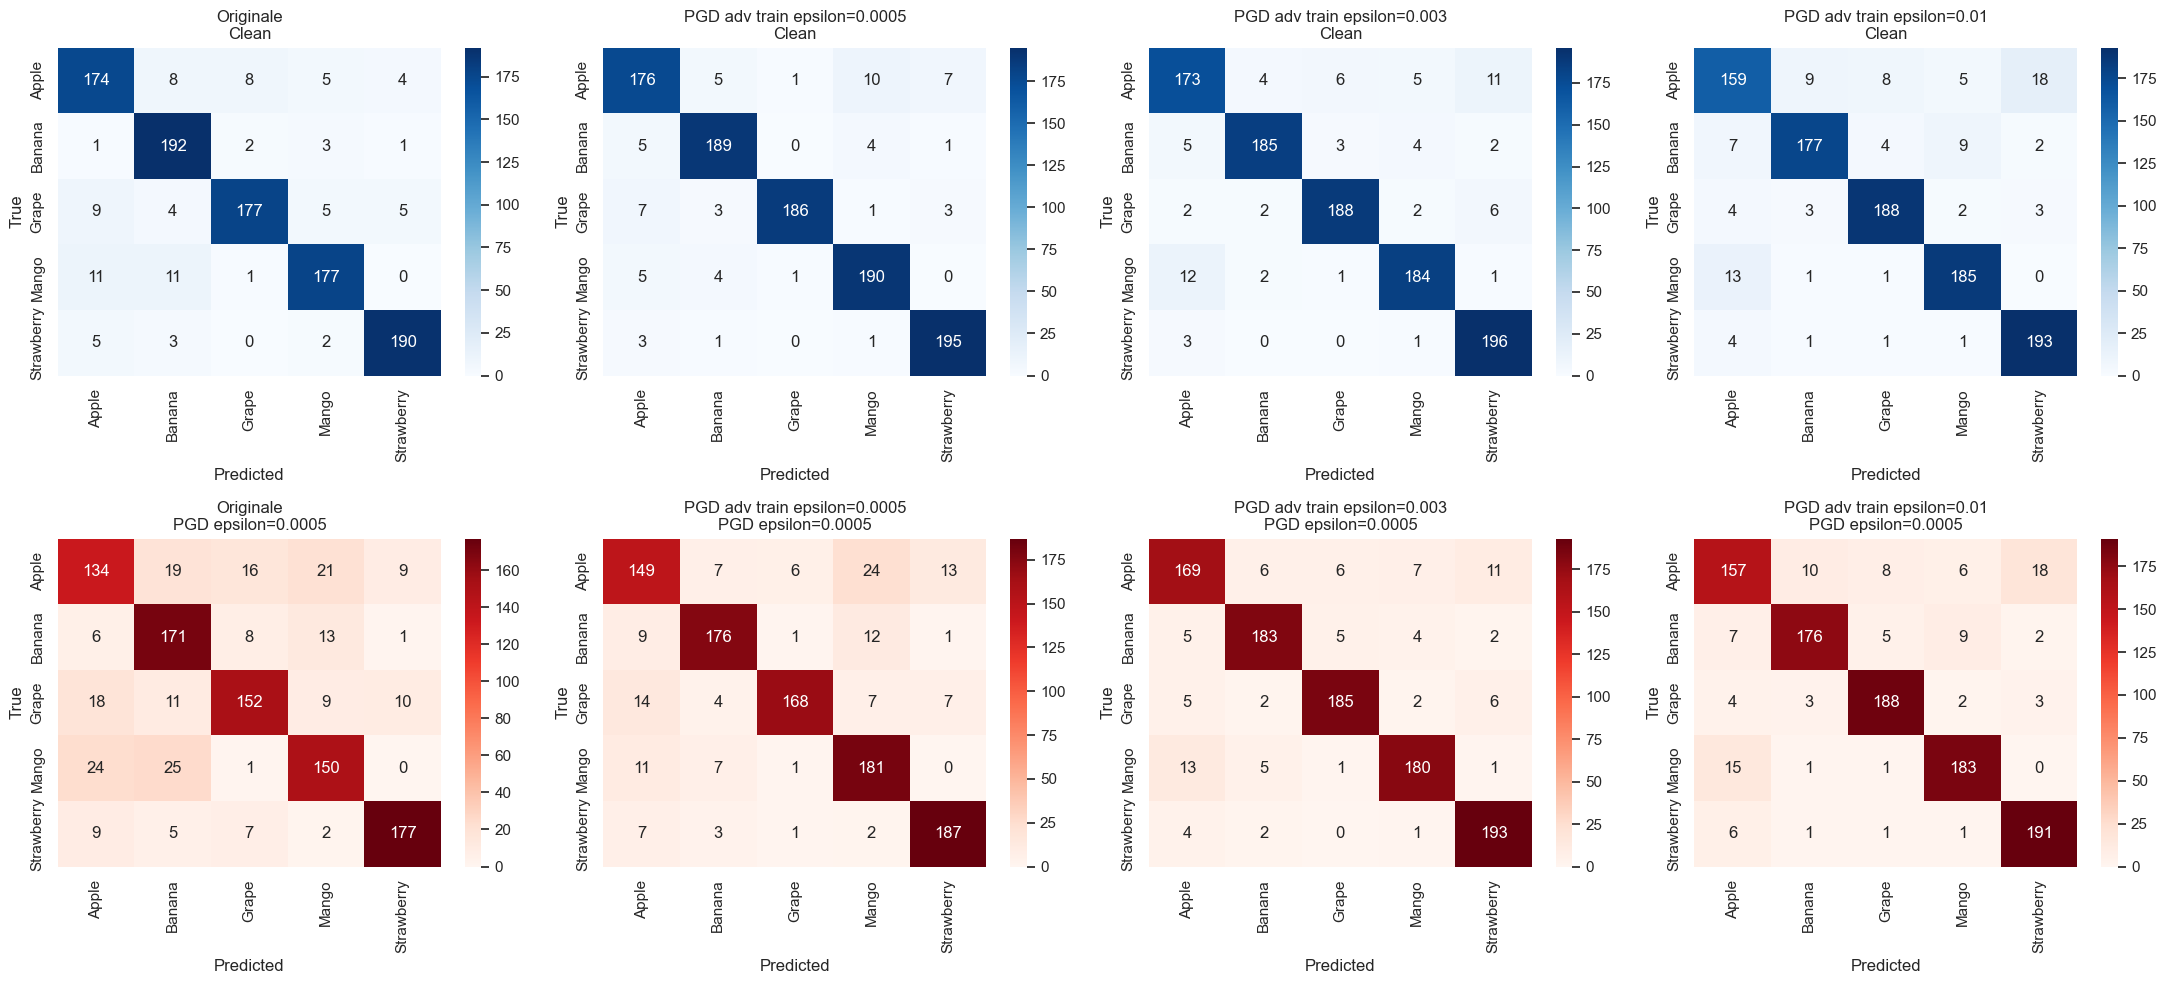


Confronto PGD con epsilon test = 0.001, alpha = 0.00025


Confronto PGD epsilon=0.001: 100%|██████████| 32/32 [00:12<00:00,  2.49it/s]


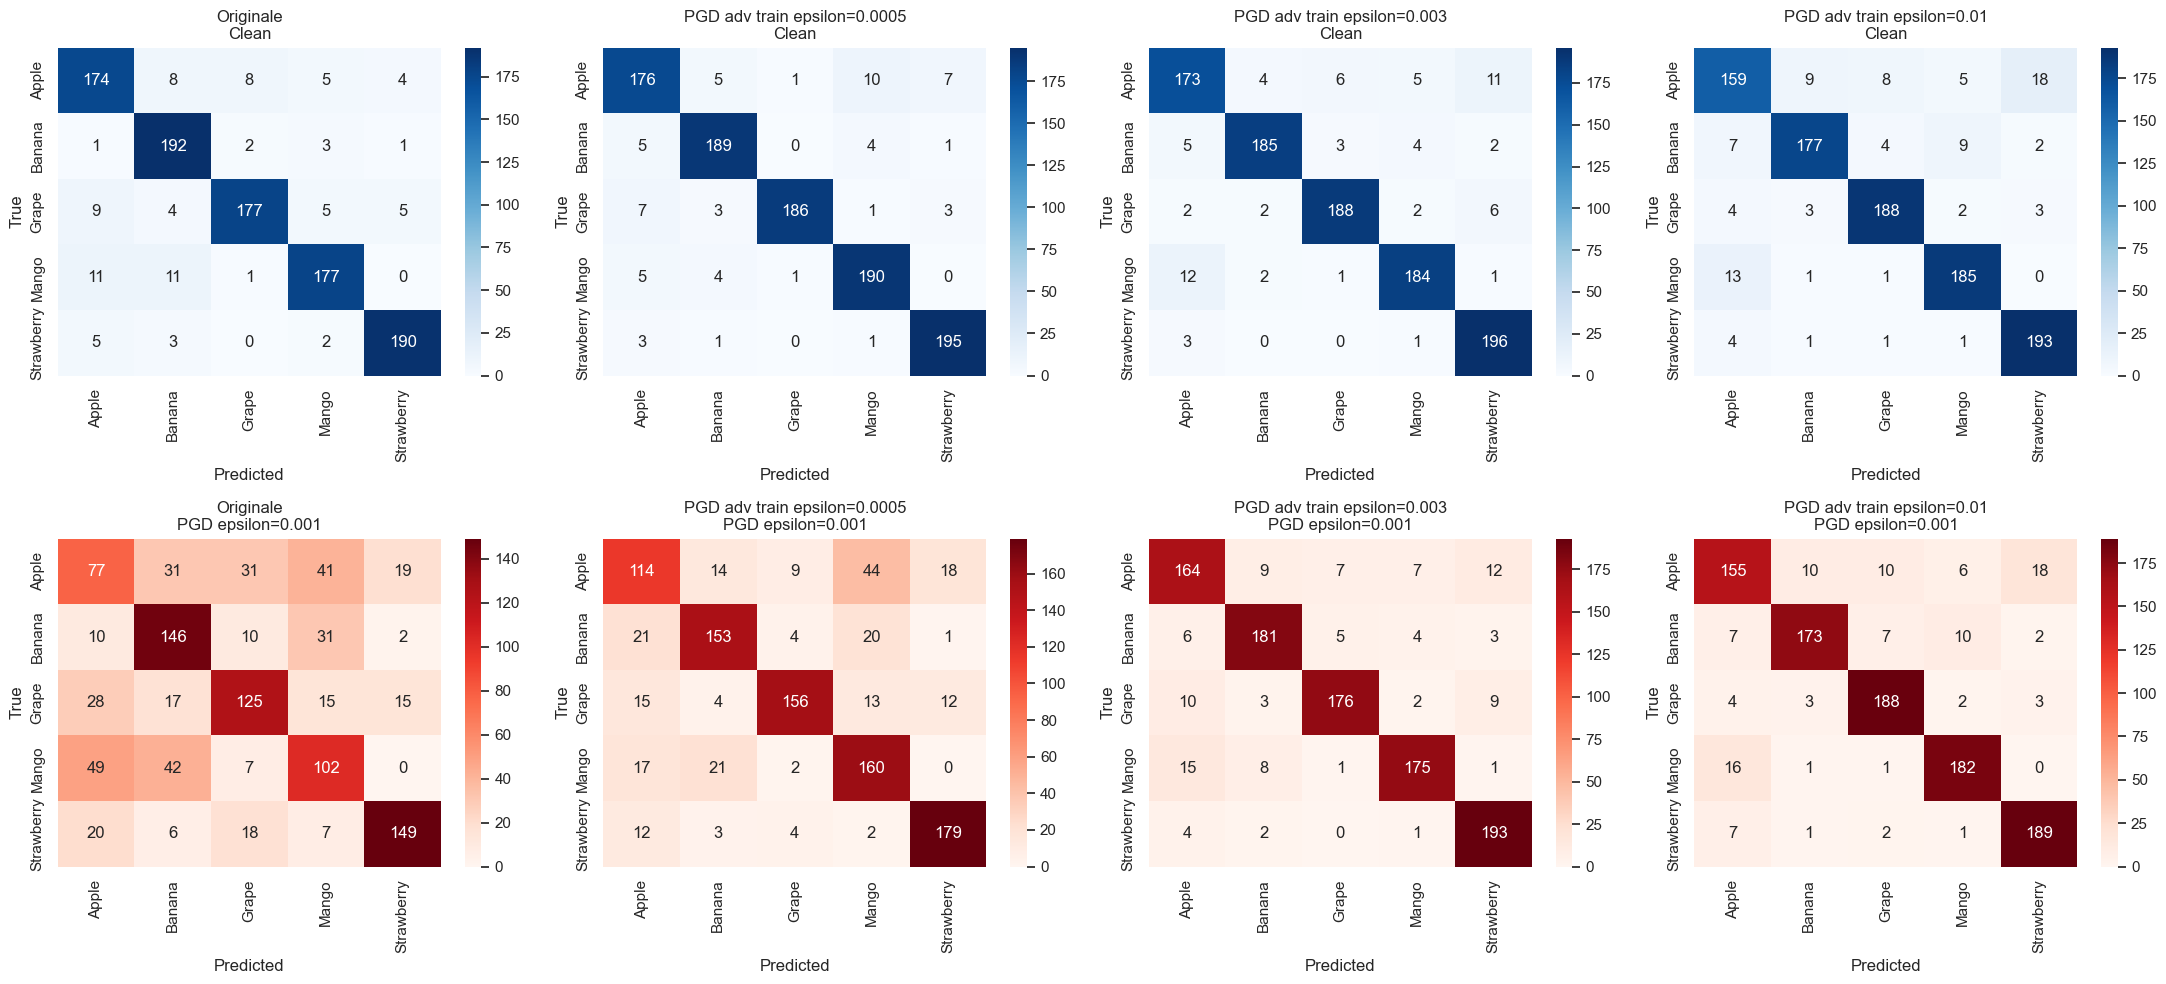


Confronto PGD con epsilon test = 0.003, alpha = 0.00075


Confronto PGD epsilon=0.003: 100%|██████████| 32/32 [00:12<00:00,  2.49it/s]


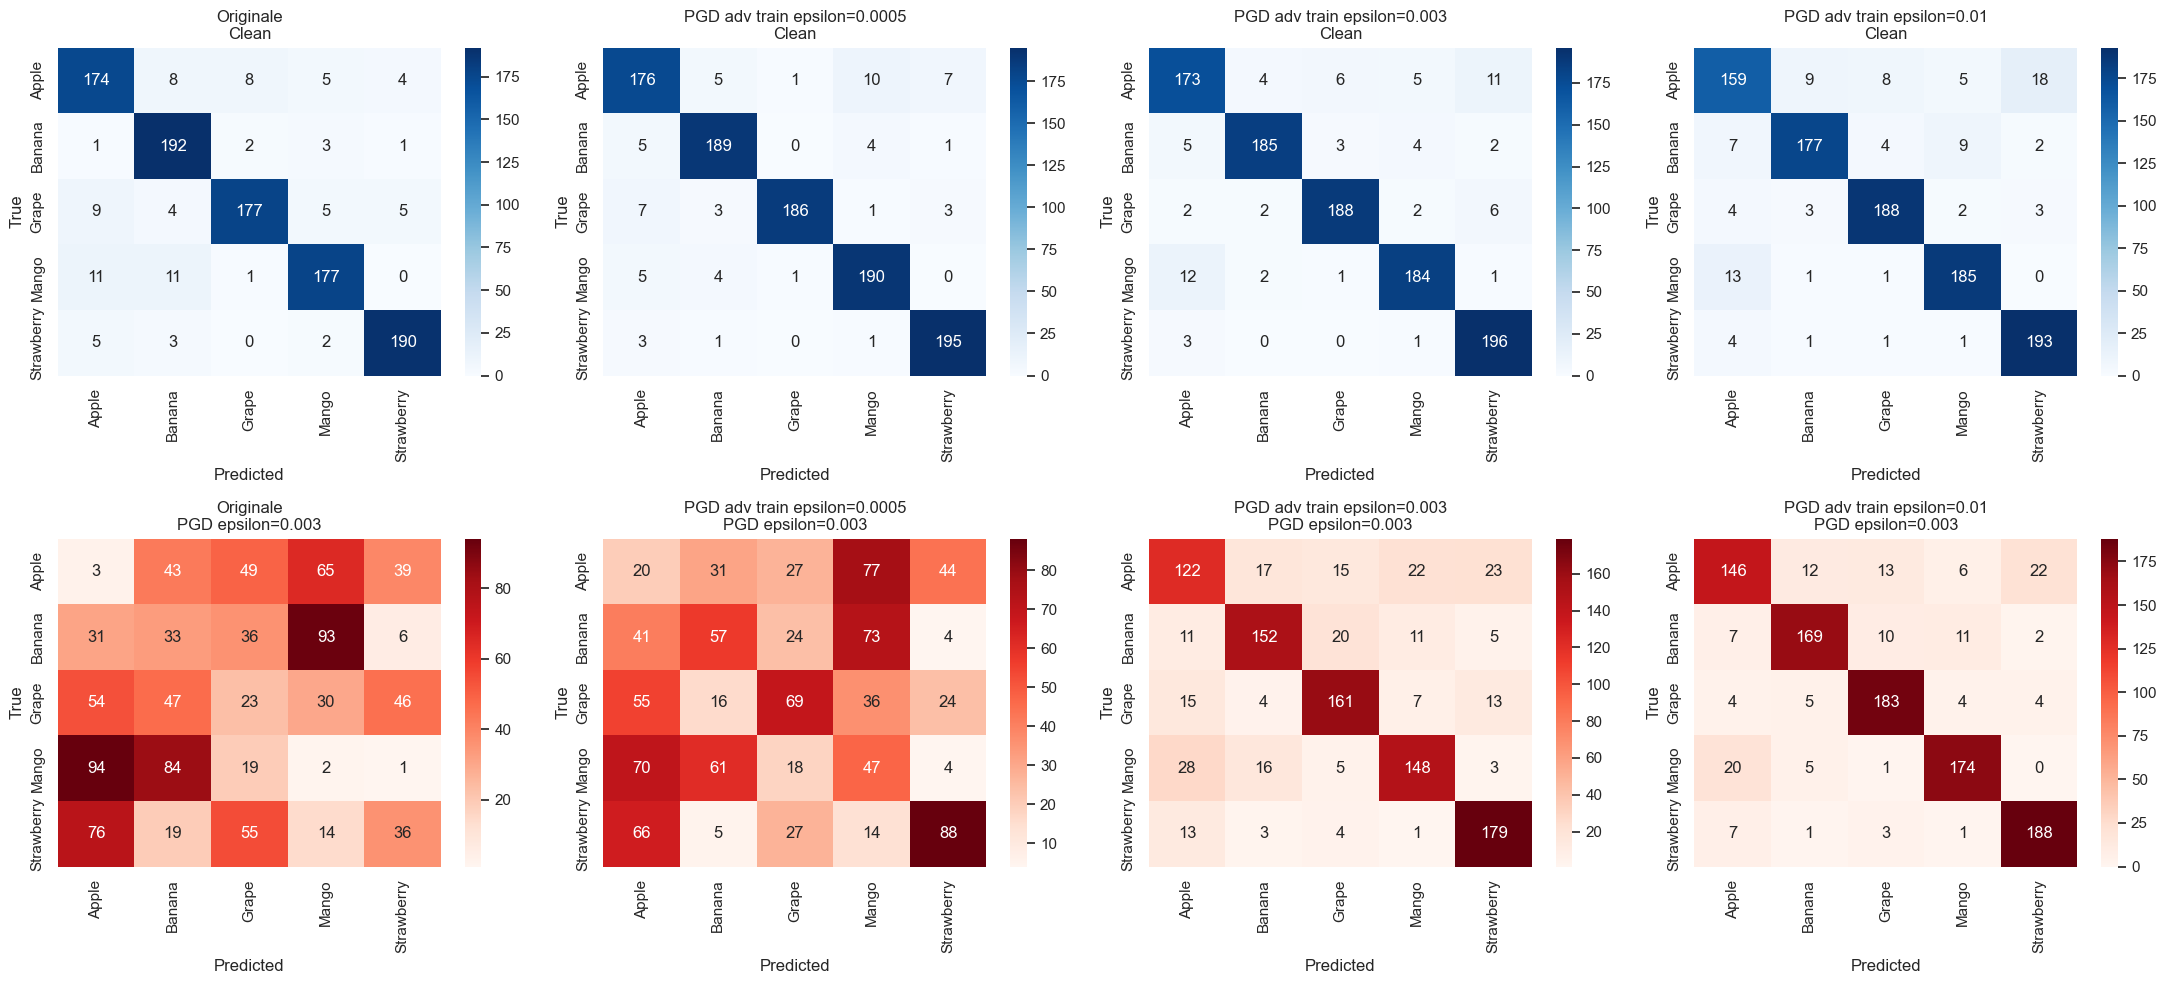


Confronto PGD con epsilon test = 0.005, alpha = 0.00125


Confronto PGD epsilon=0.005: 100%|██████████| 32/32 [00:12<00:00,  2.49it/s]


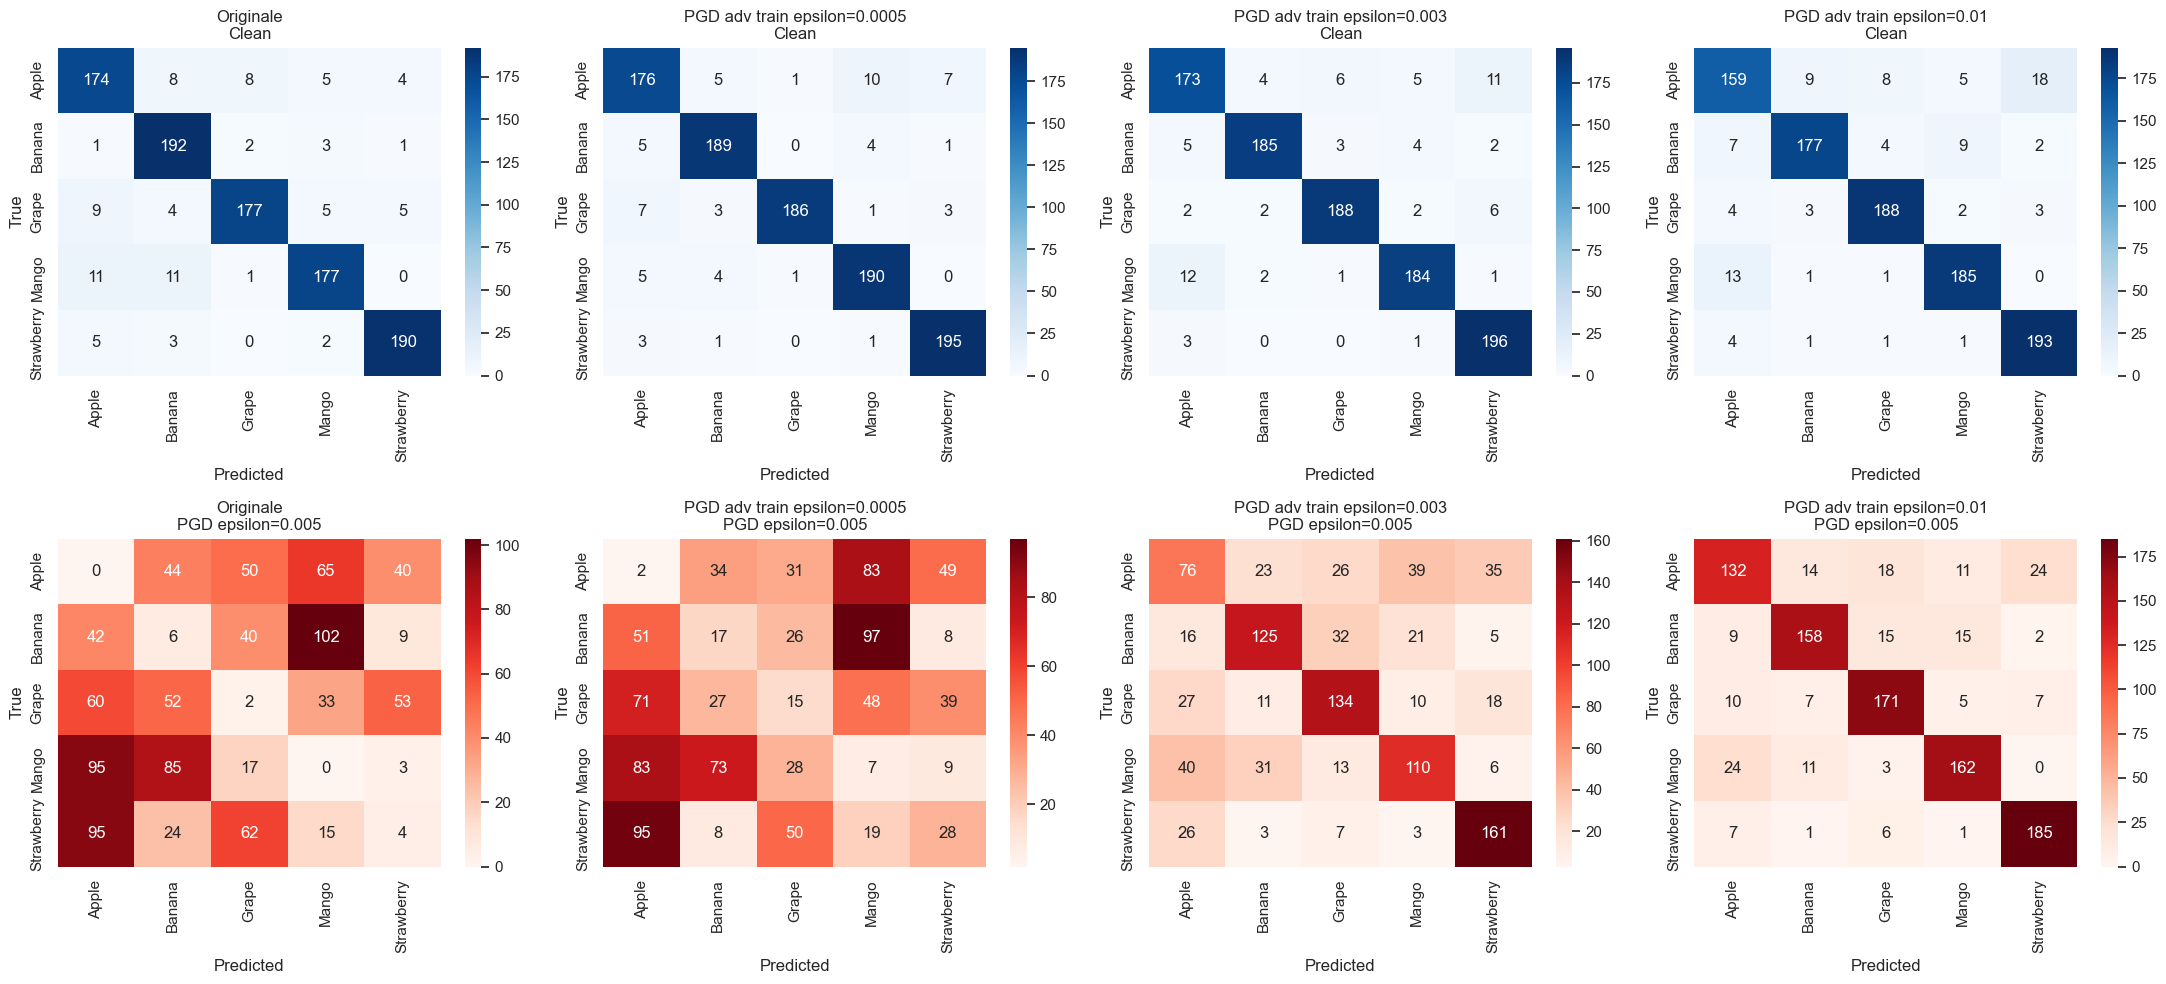


Confronto PGD con epsilon test = 0.01, alpha = 0.0025


Confronto PGD epsilon=0.01: 100%|██████████| 32/32 [00:12<00:00,  2.49it/s]


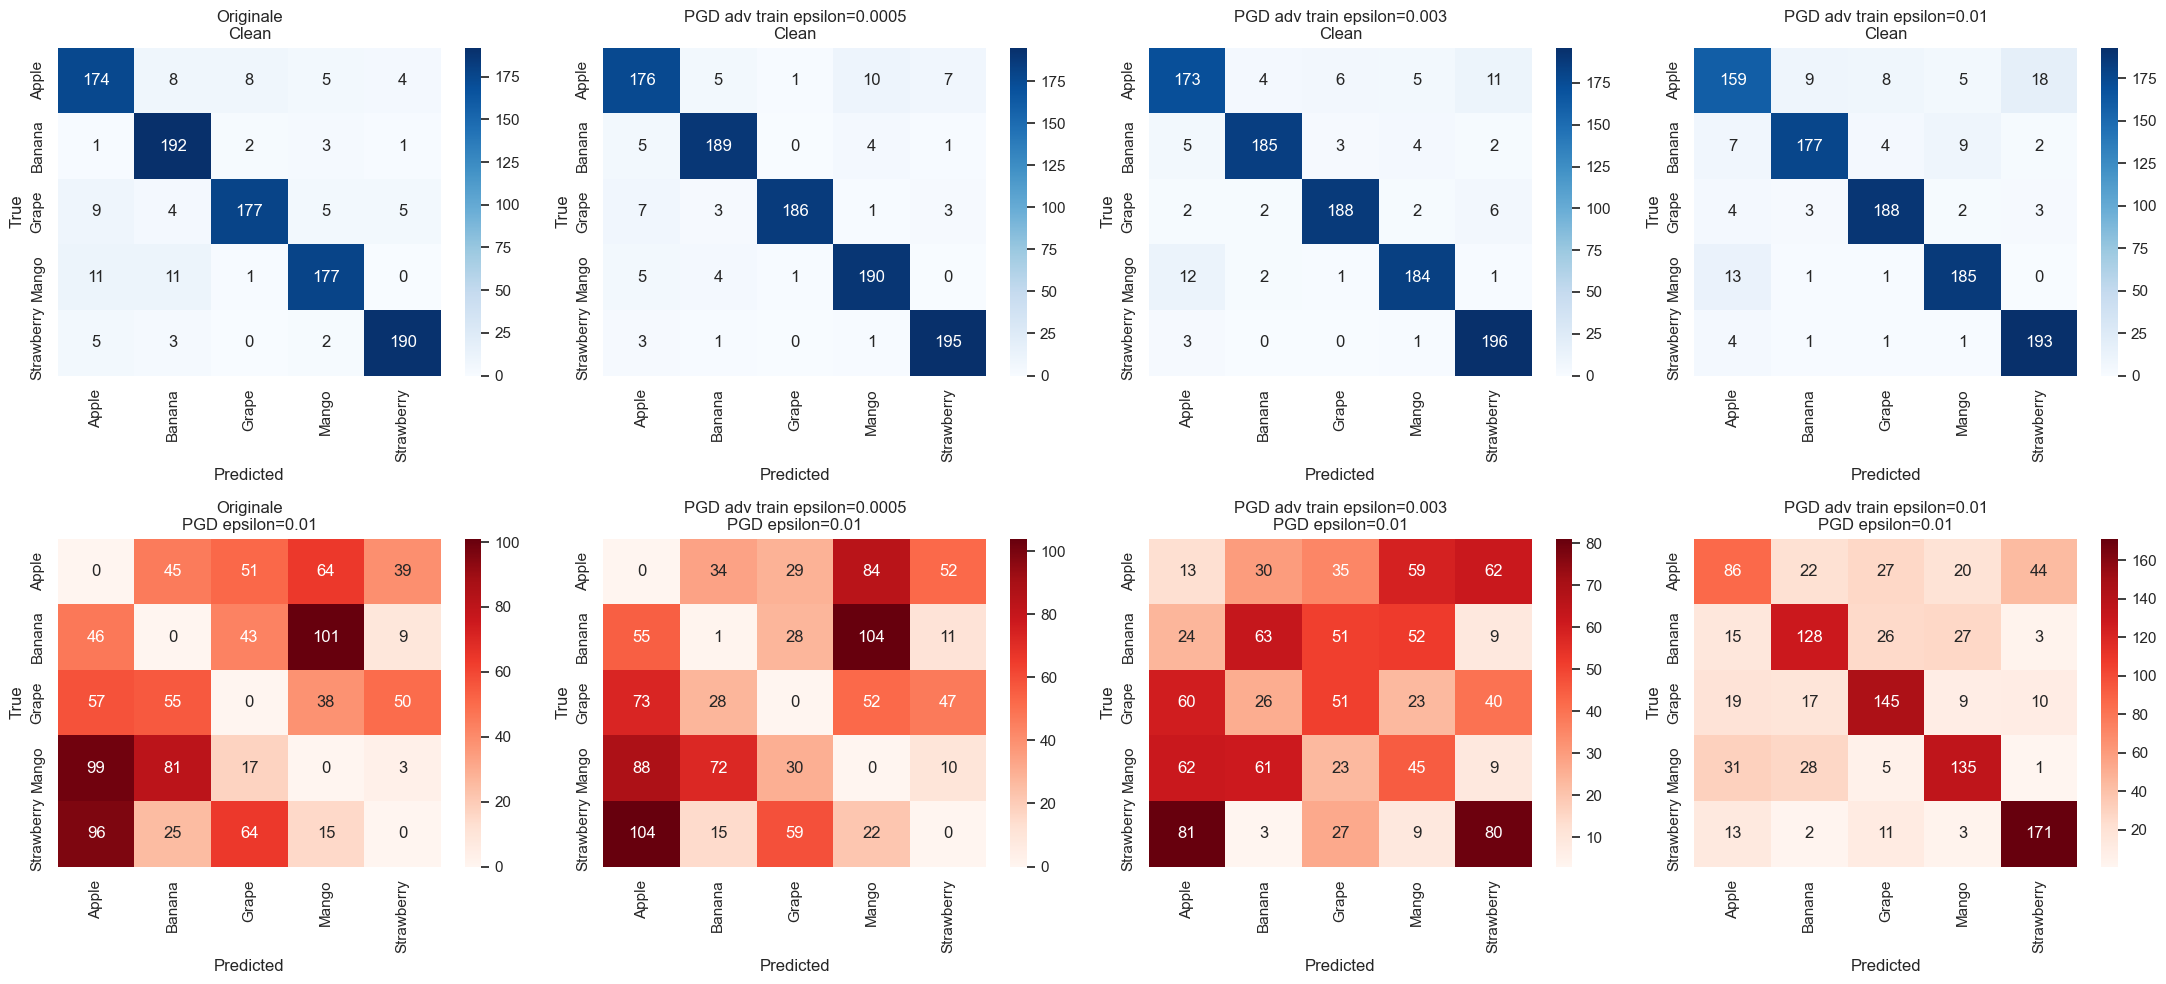

                   model  epsilon_training  epsilon_attack  accuracy_clean  accuracy_adversarial  accuracy_drop      asr
               Originale               NaN          0.0005        0.911824              0.785571       0.126253 0.138462
Adversarial Training PGD            0.0005          0.0005        0.937876              0.862725       0.075150 0.080128
Adversarial Training PGD            0.0030          0.0005        0.927856              0.911824       0.016032 0.017279
Adversarial Training PGD            0.0100          0.0005        0.903808              0.896794       0.007014 0.007761
               Originale               NaN          0.0010        0.911824              0.600200       0.311623 0.341758
Adversarial Training PGD            0.0005          0.0010        0.937876              0.763527       0.174349 0.185897
Adversarial Training PGD            0.0030          0.0010        0.927856              0.890782       0.037074 0.039957
Adversarial Training PGD        

In [7]:
epsilon_test_values = [0.0005, 0.001, 0.003, 0.005, 0.01]
num_steps_test = 10

comparison_models = {
    'Originale': {
        'model': model,
        'epsilon_training': None
    }
}

for epsilon_training in epsilon_adv_training:
    pgd_model = models.resnet18(pretrained=True)
    pgd_model.fc = nn.Linear(in_features=512, out_features=N_CLASSES)
    pgd_model = pgd_model.to(device)

    model_save_path = ROOT / "models" / f"best_pgd_{epsilon_training}.pt"
    pgd_model.load_state_dict(torch.load(model_save_path))
    pgd_model.eval()

    comparison_models[f'PGD adv train epsilon={epsilon_training}'] = {
        'model': pgd_model,
        'epsilon_training': epsilon_training
    }

model.eval()

comparison_results = []

for epsilon_test in epsilon_test_values:
    alpha_test = epsilon_test / 4

    print(f"\nConfronto PGD con epsilon test = {epsilon_test}, alpha = {alpha_test}")

    comparison_stats = {}

    for model_name in comparison_models:
        comparison_stats[model_name] = {
            'correct_clean': 0,
            'correct_adv': 0,
            'attack_success': 0,
            'preds_clean': [],
            'preds_adv': []
        }

    total = 0
    all_labels = []

    for images, labels in tqdm(test_loader, desc=f"Confronto PGD epsilon={epsilon_test}"):
        images = images.to(device)
        labels = labels.to(device)

        all_labels.extend(labels.cpu().numpy())
        total += labels.size(0)

        # valutazione modelli
        for model_name, model_info in comparison_models.items():
            current_model = model_info['model']

            # immagini pulite
            with torch.no_grad():
                outputs_clean = current_model(NORMALIZE(images))
                preds_clean = torch.argmax(outputs_clean, dim=1)

            # immagini adversarial generate contro il modello corrente
            adv_images, perturbation = pgd_attack(
                current_model,
                images.clone().detach(),
                labels,
                epsilon_test,
                alpha_test,
                num_steps_test,
                loss_fn
            )

            with torch.no_grad():
                outputs_adv = current_model(NORMALIZE(adv_images))
                preds_adv = torch.argmax(outputs_adv, dim=1)

            comparison_stats[model_name]['correct_clean'] += (preds_clean == labels).sum().item()

            comparison_stats[model_name]['correct_adv'] += (preds_adv == labels).sum().item()

            comparison_stats[model_name]['attack_success'] += ((preds_clean == labels) & (preds_adv != labels)).sum().item()

            comparison_stats[model_name]['preds_clean'].extend(preds_clean.cpu().numpy())

            comparison_stats[model_name]['preds_adv'].extend(preds_adv.cpu().numpy())

    # metriche
    for model_name, model_info in comparison_models.items():
        stats = comparison_stats[model_name]

        accuracy_clean = stats['correct_clean'] / total
        accuracy_adv = stats['correct_adv'] / total
        accuracy_drop = accuracy_clean - accuracy_adv
        asr = stats['attack_success'] / stats['correct_clean']

        if model_info['epsilon_training'] is None:
            csv_model_name = 'Originale'
        else:
            csv_model_name = 'Adversarial Training PGD'

        comparison_results.append({
            'model': csv_model_name,
            'epsilon_training': model_info['epsilon_training'],
            'epsilon_attack': epsilon_test,
            'accuracy_clean': accuracy_clean,
            'accuracy_adversarial': accuracy_adv,
            'accuracy_drop': accuracy_drop,
            'asr': asr
        })

    # plot per ogni epsilon di test
    fig, axes = plt.subplots(
        2,
        len(comparison_models),
        figsize=(22, 10)
    )

    for column, (model_name, model_info) in enumerate(
        comparison_models.items()
    ):
        stats = comparison_stats[model_name]

        cm_clean = confusion_matrix(
            all_labels,
            stats['preds_clean']
        )

        cm_adv = confusion_matrix(
            all_labels,
            stats['preds_adv']
        )

        sns.heatmap(
            cm_clean,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            ax=axes[0, column]
        )

        axes[0, column].set_title(f'{model_name}\nClean')
        axes[0, column].set_xlabel('Predicted')
        axes[0, column].set_ylabel('True')

        sns.heatmap(
            cm_adv,
            annot=True,
            fmt='d',
            cmap='Reds',
            xticklabels=class_names,
            yticklabels=class_names,
            ax=axes[1, column]
        )

        axes[1, column].set_title(
            f'{model_name}\nPGD epsilon={epsilon_test}'
        )
        axes[1, column].set_xlabel('Predicted')
        axes[1, column].set_ylabel('True')

    plt.tight_layout()

    plt.savefig(
        results_path / f"PGD_comparison_epsilon_{epsilon_test}.png",
        dpi=120,
        bbox_inches='tight'
    )

    plt.show()

# tabella riassuntiva
comparison_df = pd.DataFrame(comparison_results)

print(comparison_df.to_string(index=False))

comparison_df.to_csv(
    results_path / "PGD_original_vs_adv.csv",
    index=False
)